# 1. Using your data skills what can you tell us about this data set?

In [1]:
# Data overview

# Import of Libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

df = pd.read_csv("flood-risk-exemptions.csv")
df

,Exemption Number,Exemption Type Code,Exemption Type,Decision Date,Operator Name,Local Authority,Postcode,Grid Reference,Water Management Area
0,EXFRA004935,FRA3,Service crossing below the bed of a main river...,20/11/2018,Wales & West Utilities Limited,Stroud,GL5 2SQ,SO 86297 02810,Shropshire Herefordshire Worcestershire and Gl...
1,EXFRA011137,FRA15,Installing channel habitat structures made of ...,07/10/2022,Elan Homes Limited,Wigan,M29 7NE,SD 70622 01557,Greater Manchester Merseyside and Cheshire
2,EXFRA007178,FRA15,Installing channel habitat structures made of ...,05/05/2020,FWAG Southwest,Cotswold,GL7 4EH,SU 17900 98788,West Thames
3,EXFRA004645,FRA21,Removing silt and sand from bridge arches and ...,19/09/2018,The Environment Agency,Blackburn with Darwen,BB3 2ED,SD 70089 20900,Cumbria and Lancashire
4,EXFRA004733,FRA2,Electrical cable service crossing over a main ...,05/10/2018,Northern Powergrid,North Yorkshire,YO8 3UA,SE 56388 36322,Yorkshire
...,...,...,...,...,...,...,...,...,...
10258,EXFRA010854,FRA12,Outfall pipes less than 300mm diameter through...,15/08/2022,Oslac Ltd,Chichester,PO20 7AF,SZ 82398 97486,Solent and South Downs
10259,EXFRA002067,FRA3,Service crossing below the bed of a main river...,14/03/2017,WESTERN POWER DISTRIBUTION (EAST MIDLANDS) PLC,North Northamptonshire,LE16 8LW,SP 75848 84334,Lincolnshire and Northamptonshire
10260,EXFRA005806,FRA12,Outfall pipes less than 300mm diameter through...,21/06/2019,Hill Partnership Limited,Lewes,BN9 0FE,TQ 45196 01320,Solent and South Downs
10261,EXFRA014876,FRA14,Repairing bank slips and erosion using the fal...,05/02/2025,jason allen,East Staffordshire,ST14 5AB,SK 08590 34874,Staffordshire Warwickshire and West Midlands


In [2]:
# Data Quality
# 1. Checking missing values
# Count missing values per column
missing_counts = df.isna().sum()
#missing_counts

# Calculate percentage of missing values per column
missing_percent = (df.isna().mean() * 100).round(4)

# Combine results into a single table
missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage (%)": missing_percent
})
missing_summary

# After identify the missing data, as are less than 1% they can be kept, excluded or corrected manually
#missing_records = df[df.isna().any(axis=1)]
#missing_records

,Missing Count,Missing Percentage (%)
Exemption Number,0,0.0000
Exemption Type Code,0,0.0000
Exemption Type,0,0.0000
Decision Date,16,0.1559
Operator Name,0,0.0000
Local Authority,14,0.1364
Postcode,14,0.1364
Grid Reference,0,0.0000
Water Management Area,14,0.1364


In [3]:
# 2. Checking duplicates
df.duplicated().sum()

np.int64(0)

In [4]:
# Count records by exemption code and type
exemption_table = (
    df
    .groupby(["Exemption Type Code", "Exemption Type"])
    .size()
    .reset_index(name="Number of Records")
    .sort_values("Number of Records", ascending=False)
)

#exemption_table

# Top 5 most common
top_5 = exemption_table.head(5).copy()
top_5["Category"] = "Top 5 (Most Common)"

# Bottom 3 least common
bottom_3 = exemption_table.tail(3).copy()
bottom_3["Category"] = "Bottom 3 (Least Common)"

# Combine
summary_table = pd.concat([top_5, bottom_3])

summary_table

,Exemption Type Code,Exemption Type,Number of Records,Category
26,FRA9,Maintaining structures within the channel of a...,2059,Top 5 (Most Common)
2,FRA12,Outfall pipes less than 300mm diameter through...,1096,Top 5 (Most Common)
20,FRA3,Service crossing below the bed of a main river...,920,Top 5 (Most Common)
25,FRA8,Maintaining a raised river defence or sea defe...,918,Top 5 (Most Common)
23,FRA6,Temporary scaffolding in or over a main river ...,700,Top 5 (Most Common)
17,FRA26,Constructing raised flood defences around a ma...,36,Bottom 3 (Least Common)
0,FRA10,Constructing drinking bays for livestock on th...,35,Bottom 3 (Least Common)
11,FRA20,Constructing fish passage notches in an existi...,22,Bottom 3 (Least Common)


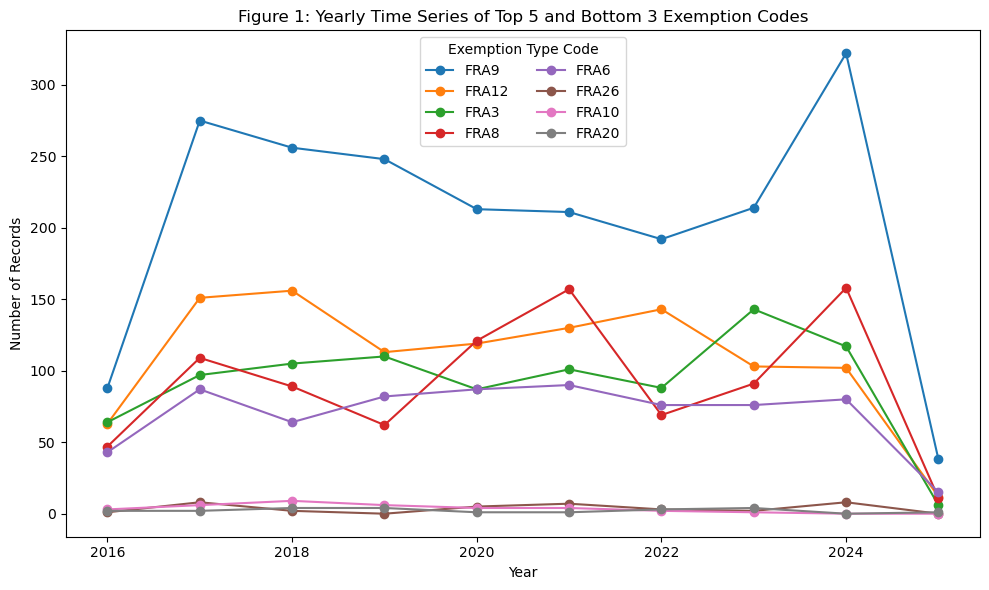

Exemption Type Code,FRA9,FRA12,FRA3,FRA8,FRA6,FRA26,FRA10,FRA20
Year,,,,,,,,
2016.0,88.0,63.0,64.0,47.0,43.0,1.0,3.0,2.0
2017.0,275.0,151.0,97.0,109.0,87.0,8.0,6.0,2.0
2018.0,256.0,156.0,105.0,89.0,64.0,2.0,9.0,4.0
2019.0,248.0,113.0,110.0,62.0,82.0,0.0,6.0,4.0
2020.0,213.0,119.0,87.0,121.0,87.0,5.0,4.0,1.0
2021.0,211.0,130.0,101.0,157.0,90.0,7.0,4.0,1.0
2022.0,192.0,143.0,88.0,69.0,76.0,3.0,2.0,3.0
2023.0,214.0,103.0,143.0,91.0,76.0,2.0,1.0,4.0
2024.0,322.0,102.0,117.0,158.0,80.0,8.0,0.0,0.0


In [5]:
# Load the data for temporal analysis
df = pd.read_csv("flood-risk-exemptions.csv")

# Convert Decision Date to datetime and extract Year
df["Decision Date"] = pd.to_datetime(df["Decision Date"], errors="coerce", dayfirst=True)
df["Year"] = df["Decision Date"].dt.year

# Count records per Year and Exemption Type Code
year_code_counts = (
    df.groupby(["Year", "Exemption Type Code"])
      .size()
      .reset_index(name="Number of Records")
)

# Create pivot table
pivot_ts = (
    year_code_counts
    .pivot(index="Year", columns="Exemption Type Code", values="Number of Records")
    .fillna(0)
    .sort_index()
)

# Identify top 5 and bottom 3 exemption codes
total_counts = pivot_ts.sum().sort_values(ascending=False)

top_5_codes = total_counts.head(5).index
bottom_3_codes = total_counts.tail(3).index

# Combine codes
selected_codes = list(top_5_codes) + list(bottom_3_codes)

pivot_selected = pivot_ts[selected_codes]

# Plot time series
plt.figure(figsize=(10, 6))

for code in pivot_selected.columns:
    plt.plot(
        pivot_selected.index,
        pivot_selected[code],
        marker="o",
        label=code
    )

plt.title("Figure 1: Yearly Time Series of Top 5 and Bottom 3 Exemption Codes")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.legend(title="Exemption Type Code", ncol=2)
plt.tight_layout()
plt.show()

# Display the table used for the plot
pivot_selected


Text(0.5, 1.0, 'UK Locations')

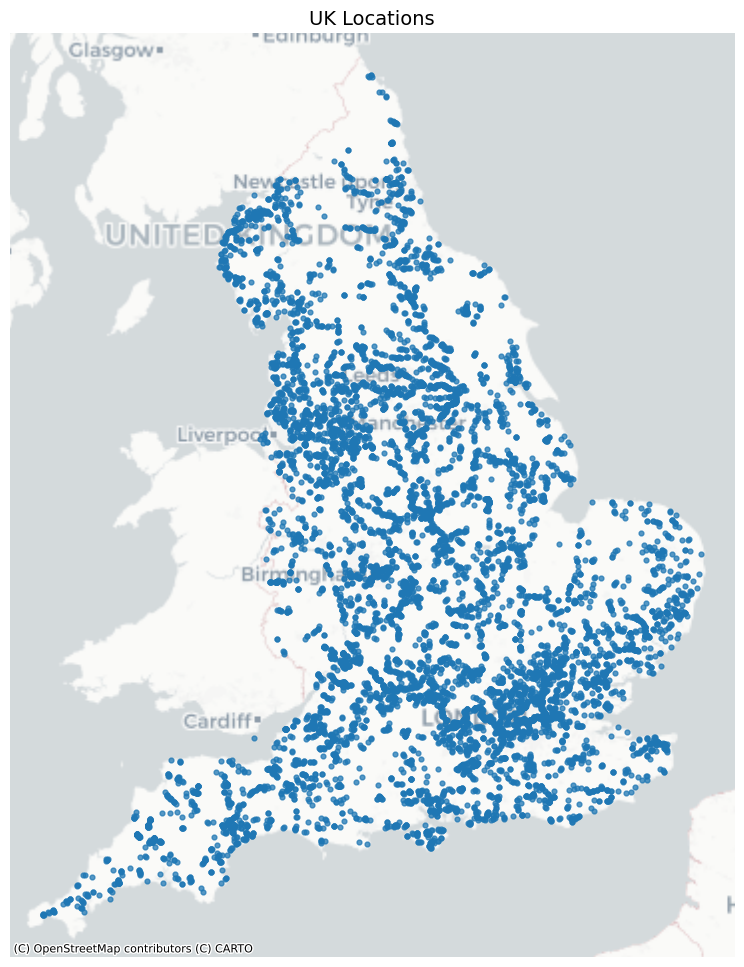

In [6]:
# Spatial distribution
# Focused on the distribution of the area exempted using their Latitude and Longitude
# Grid reference points were converted to Latitude and Longitude using the following links and excel sheet
       #Links for convertion: https://gridreferencefinder.com/batchConvert/batchConvert.php																					
       #Link for validation: https://gridreferencefinder.com/?&v=r&labels=1#gr=SO8629702810|SO_s_86297_s_02810|1 	

# Load data
file_path = "Grid reference change work.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 12))

gdf.plot(ax=ax, markersize=12, alpha=0.75, zorder=3)

providers_to_try = [
    ctx.providers.CartoDB.Positron,        # clean, dark labels, good boundaries
    ctx.providers.OpenStreetMap.Mapnik,    # black labels, reliable
    ctx.providers.Esri.WorldGrayCanvas     # darker boundaries, labels ok
]
# Make a clear plot
basemap_added = False
last_err = None

for prov in providers_to_try:
    try:
        ctx.add_basemap(ax, source=prov, zoom=6)
        basemap_added = True
        break
    except Exception as e:
        last_err = e

if not basemap_added:
    print("WARNING: Basemap could not be downloaded. Plotting points only.")
    print("Last error:", last_err)

ax.set_axis_off()
ax.set_title("UK Locations", fontsize=14)

#fig
# Save output
#fig
#fig.savefig("uk_points_basemap_1.png", dpi=600, bbox_inches="tight")
#plt.close(fig)
